<a href="https://colab.research.google.com/github/Evelyn-Rojas/Procesos-Estocasticos/blob/main/TutorialSympy.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<font color="mediumslateblue">**Evelyn Tania Rojas Roa**

<font color="mediumslateblue">**Procesos Estocásticos**

---



# <font color="lightseagreen"> **Multiplicar matrices**

---



SymPy es una librería de Python para matemáticas simbólicas.
Permite trabajar con:

- Variables simbólicas

- Expresiones algebraicas

- Operaciones exactas (sin aproximaciones decimales)



> **1. Importamos la librería Sympy**



In [2]:
import sympy as sp



> **2. Creamos una matriz**



In [3]:
A = sp.Matrix([
    [1, 2],
    [3, 4]])

In [4]:
A #Visualizamos la matriz

Matrix([
[1, 2],
[3, 4]])

In [5]:
B = sp.Matrix([
    [5, 6],
    [7, 8]
])
B

Matrix([
[5, 6],
[7, 8]])

### Multiplicación de Matrices

Sean:

$$
A \in \mathbb{R}^{m \times n}
\quad \text{y} \quad
B \in \mathbb{R}^{n \times p}
$$

Esto significa que:

- La matriz $A$ tiene $m$ filas y $n$ columnas.
- La matriz $B$ tiene $n$ filas y $p$ columnas.


El producto matricial $AB$ está definido **si y solo si** el número de columnas de $A$ coincide con el número de filas de $B$, es decir:

$$
\text{Columnas de } A = \text{Filas de } B = n
$$

Cuando esta condición se cumple, el producto $AB$ existe.



---


Sea $C = AB$. El elemento $(i,j)$ de la matriz producto se define como:

$$
c_{ij} = \sum_{k=1}^{n} a_{ik} b_{kj}
$$

Donde:

- $a_{ik}$ es el elemento de $A$ en la fila $i$, columna $k$.
- $b_{kj}$ es el elemento de $B$ en la fila $k$, columna $j$.
- $c_{ij}$ es el elemento del producto en la fila $i$, columna $j$.





> **3. Multiplicamos las matrices**



In [6]:
C = A * B #En sympy se usa el operador *
C

Matrix([
[19, 22],
[43, 50]])



> <font color= "mediumturquoise"> **Multipicación de matrices con variables simbólicas**



In [7]:
x, y = sp.symbols('x y')

A = sp.Matrix([
    [x, 1],
    [2, y]
])

B = sp.Matrix([
    [1, x],
    [y, 2]
])

C = A * B
C

Matrix([
[   x + y,  x**2 + 2],
[y**2 + 2, 2*x + 2*y]])

### <font color="lightseagreen"> **Obtener el renglón de una matriz**

---

In [8]:
A.row(0)

Matrix([[x, 1]])

### <font color="lightseagreen"> **Obtener una columna de una matriz**

---

In [9]:
A.col(1)

Matrix([
[1],
[y]])

### <font color="lightseagreen"> **Elevar a la potencia una matriz**

In [10]:
A**2

Matrix([
[ x**2 + 2,    x + y],
[2*x + 2*y, y**2 + 2]])

### <font color="lightseagreen"> **Multiplicar una matriz por un vector**

In [11]:
v = sp.Matrix([1,2])

A*v

Matrix([
[  x + 2],
[2*y + 2]])

# <font color="lightseagreen"> **Dibujar diagramas de transición**

---

**NetworkX** es una librería de Python para trabajar con:

* Grafos

* Redes

* Teoría de grafos

* Caminos, ciclos, centralidad, etc.

Permite crear y analizar grafos de manera sencilla.

---





>**<font color='salmon'> Importamos la librería**



In [ ]:
import networkx as nx
import matplotlib.pyplot as plt

 > <font color='salmon'> **Creación de un grafo no dirigido vacío**




In [ ]:
G = nx.Graph()

 <font color='salmon'> **Añadir nodos**


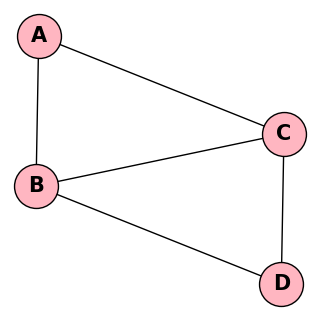

In [ ]:
G.add_edge('A','B', capacity=2) #Recordar que capacity es cuantos arcos puede tener el nodo
G.add_edge('A','C', capacity=2)
G.add_edge('B','D', capacity=2)
G.add_edge('C','D', capacity=2)
G.add_edge('B','C', capacity=2)
plt.figure(figsize=(3,3))
nx.draw(G, with_labels=True, node_color="lightpink",
       node_size=1000, font_size=15, font_weight="bold",
        arrowsize=50, edgecolors="black")
plt.show()
#En los nombres del nodo podemos poner cada estado de nuestro sistema

> <font color='orange'> NOTA: El orden de los informes de adyacencia corresponde al orden de adición de las aristas.

 <font color='salmon'> **Gráficos dirigidos**

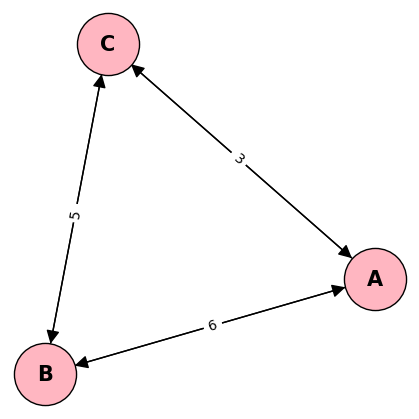

In [ ]:
G = nx.DiGraph()

# Agregar nodos
G.add_node("A")
G.add_node("B")
G.add_node("C")

# Agregar aristas dirigidas
G.add_edge("A", "B", weight=1)
G.add_edge("B", "C",weight=2)
G.add_edge("C", "A",weight=3)
G.add_edge("A", "C",weight=4)
G.add_edge("C", "B",weight=5)
G.add_edge("B", "A",weight=6)
plt.figure(figsize=(4,4))
nx.draw(G, with_labels=True, node_color="lightpink",
        node_size=2000, font_size=15, font_weight="bold",
        arrowsize=20, edgecolors="black")
pos = nx.spring_layout(G)
etiquetas_aristas = nx.get_edge_attributes(G, 'weight')
nx.draw_networkx_edge_labels(G,pos, edge_labels=etiquetas_aristas)
plt.show()

 <font color='salmon'> **Ejemplo de un diagrama de transición**

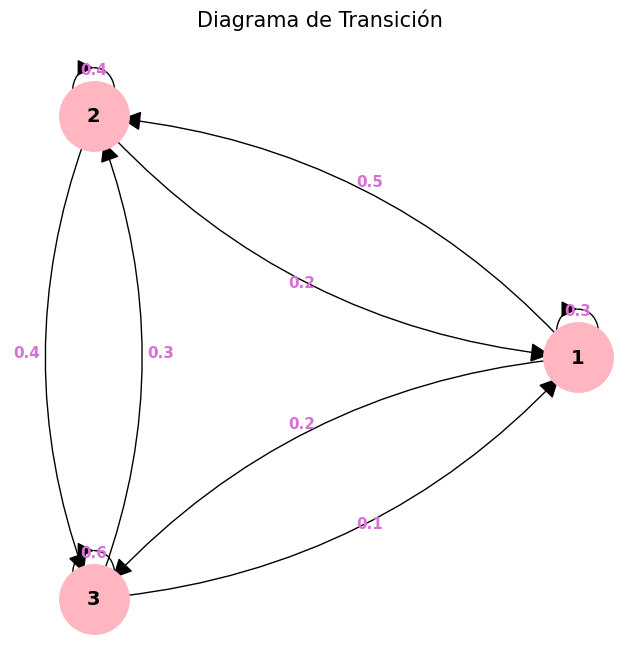

In [17]:
import networkx as nx
import matplotlib.pyplot as plt

# Crear grafo dirigido
G = nx.DiGraph()

# Transiciones con probabilidades
edges = [
    (1, 2, 0.5), (2, 1, 0.2),
    (1, 3, 0.2), (3, 1, 0.1),
    (2, 3, 0.4), (3, 2, 0.3),
    (1, 1, 0.3), (2, 2, 0.4), (3, 3, 0.6)
]

for u, v, w in edges:
    G.add_edge(u, v, weight=w)

pos = nx.circular_layout(G)
plt.figure(figsize=(8, 8))

# 1. Dibujar Nodos
nx.draw_networkx_nodes(G, pos, node_color="lightpink", node_size=2500)
nx.draw_networkx_labels(G, pos, font_size=14, font_weight='bold')

# 2. Dibujar Aristas con curvatura para separar ida y vuelta
# connectionstyle y min_source_margin para que no toquen el centro del nodo
nx.draw_networkx_edges(
    G, pos,
    edgelist=[e for e in G.edges() if e[0] != e[1]], # Aristas externas
    arrowstyle='-|>',
    arrowsize=30,
    edge_color='black',
    connectionstyle='arc3,rad=0.2', # Crea la curva para separar flechas
    min_source_margin=20,
    min_target_margin=20
)

# 3. Dibujar Self-loops (bucles sobre el mismo nodo)
nx.draw_networkx_edges(
    G, pos,
    edgelist=[e for e in G.edges() if e[0] == e[1]], # Bucles
    arrowstyle='-|>',
    arrowsize=25,
    connectionstyle='arc3,rad=0.5',
    min_source_margin=20,
    min_target_margin=20
)

# 4. Etiquetas de probabilidad personalizadas
# Para evitar que se encimen, calculamos la posición manualmente
edge_labels = nx.get_edge_attributes(G, 'weight')

# Dibujamos las etiquetas con una rotación y desplazamiento
for (u, v), weight in edge_labels.items():
    # Calcular punto medio de la arista
    x = (pos[u][0] + pos[v][0]) / 2
    y = (pos[u][1] + pos[v][1]) / 2

    # Añadir un pequeño desfase para que no se pisen
    if u != v:
        # Desplazamiento ortogonal básico para curvas
        x += (pos[v][1] - pos[u][1]) * 0.12
        y += (pos[u][0] - pos[v][0]) * 0.12
    else:
        # Desplazamiento para los bucles (arriba del nodo)
        y += 0.15

    plt.text(x, y, s=weight, size=11, color="Orchid",
             family='sans-serif', weight='bold',
             horizontalalignment='center')

plt.title("Diagrama de Transición", fontsize=15)
plt.axis("off")
plt.show()